<a href="https://colab.research.google.com/github/meghana507/ai-ml-practice-project/blob/main/Convolutional_Neural_Network_and_hyperparameter_tuning_in_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steps to build CNN to solve Emergency vs Non-Emergency vehicle classification problem

1. Loading the Dataset
2. Pre-processing the Data
3. Creating Training and Validation set
4. Defining the Model Architecture
5. Compiling the Model
6. Training the Model
7. Evaluating model performance

## 1. Loading the Dataset

In [1]:
# import necessary libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# importing layers from keras
from keras.layers import Dense, InputLayer, BatchNormalization, Dropout
from keras.models import Sequential
# importing adam optimizer from keras optimizer module
from keras.optimizers import Adam

# train_test_split to create training and validation set
from sklearn.model_selection import train_test_split
# accuracy_score to calculate the accuracy of predictions
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# unzipping the Dataset.zip file
!unzip /content/drive/My\ Drive/images.zip

Archive:  /content/drive/My Drive/images.zip
replace images/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
# create random number generator
seed = 42

In [5]:
# reading the csv file
data = pd.read_csv('/content/emergency_classification.csv')

In [6]:
# load images and store it in numpy array

# empty list to store the images
X = []
# iterating over each image
for img_name in data.image_names:
    # loading the image using its name
    img = plt.imread('images/' + img_name)
    # saving each image in the list
    X.append(img)

# converting the list of images into array
X=np.array(X)

# storing the target variable in separate variable
y = data.emergency_or_not.values

In [7]:
# shape of the images
X.shape

(2352, 224, 224, 3)

## 2. Pre-processing the Data

In [8]:
# since we are using CNN, we do not have to resize the images into 1D array.

In [9]:
# normalizing the pixel values
X = X / X.max()

## 3. Creating Training and Validation set

In [10]:
# creating a training and validation set
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.3, random_state=seed)

In [11]:
# shape of training and validation set
(X_train.shape, y_train.shape), (X_valid.shape, y_valid.shape)

(((1646, 224, 224, 3), (1646,)), ((706, 224, 224, 3), (706,)))

## 4. Defining the Model Architecture

![alt text](https://drive.google.com/uc?id=1qsops2ZfESuzjg7-V0rmOfVE0PtErYrJ)

In [12]:
# importing the convolutional and flatten layer from keras
from keras.layers import Conv2D, Flatten

In [13]:
# defining the model architecture

# creating a sequential model
model = Sequential()

# defining input layer with 3D input of shape (224,224,3)
model.add(InputLayer(input_shape=(224, 224, 3)))

# defining the first convolutional layer with 25 filters of size (5,5)
model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
# defining the second convolutional layer with 50 filters of size (5,5)
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))

# flattening the output from convolutional layers so that it can be forwarded to the dense layers
model.add(Flatten())

# defining the first dense or fully connected layer with 100 neurons
model.add(Dense(units=100, activation='sigmoid'))
# defining the output layer with 1 neuron since it is a binary classification problem
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [14]:
# printing summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 25)   │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 216, 216, 50)   │        31,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2332800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │   233,280,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,313,401 (890.02 MB)

 Trainable params: 233,313,401 (890.02 MB)

 Non-trainable params: 0 (0.00 B)

## Understanding the Architecture
*  Input shape is (224,224,3) since images are of this shape
*  We then applied 25 filters each of shape (5,5) and stride is (1,1)
*  So the output from first convolutional layer is: **(224-5+1,224-5+1,25)** which is **(220,220,25)**
*  We then applied 50 filters of shape (5,5) each with stride (1,1)
*  Then the output is **(220-5+1,220-5+1,50)** which is **(216,216,50)**
*  Then this output is flattened which resulted in 216 X 216 X 50 = 2332800 features
*  Finally these features are passed through the fully connected layers.


## Understanding the number of parameters of different layers

1.   First Convolutional Layer
    * Number of input channels = 3
    * Number of filters = 25
    * Filter Size = (5,5)
    * Learnable parameters = **25 * 5 * 5 * 3 + 25** (1 bias for each filter) = **1900**
2.   Second Convolutional Layer
    * Number of input channels = 25
    * Number of filters = 50
    * Filter Size = (5,5)
    * Learnable parameters = **50 * 5 * 5 * 25 + 50** (1 bias for each filter) = **31300**
3.   First Fully Connected Layer
    * Number of input features = 216 * 216 * 50 = 2332800
    * Number of neurons in this hidden layer = 100
    * Learnable parameters = **2332800 * 100 + 100** (1 bias for each neuron) = **233280100**
3.   Output Layer
    * Number of input features = 100
    * Number of neurons in this layer = 1
    * Learnable parameters = **100 * 1 + 1** (1 bias for each neuron) = **101**



## 5. Compiling the Model

In [15]:
# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

## 6. Training the Model

In [16]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - accuracy: 0.5487 - loss: 0.8314 - val_accuracy: 0.6700 - val_loss: 0.6122
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 164ms/step - accuracy: 0.6412 - loss: 0.6225 - val_accuracy: 0.6445 - val_loss: 0.6190
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.6788 - loss: 0.6075 - val_accuracy: 0.6926 - val_loss: 0.5893
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.7081 - loss: 0.5708 - val_accuracy: 0.6841 - val_loss: 0.5621
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.7383 - loss: 0.5364 - val_accuracy: 0.7337 - val_loss: 0.5368
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.7652 - loss: 0.4943 - val_accuracy: 0.7323 - val_loss: 0.5168
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.8144 - loss: 0.4523 - val_accuracy: 0.7068 - val_loss: 0.5619
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.8144 - loss: 0.4348 - val_accuracy

## 7. Evaluating model performance

In [17]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] >= 0.5, 1, 0)))

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step
Accuracy on training set: 0.9100850546780073


In [18]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Accuracy on validation set: 0.7747875354107648


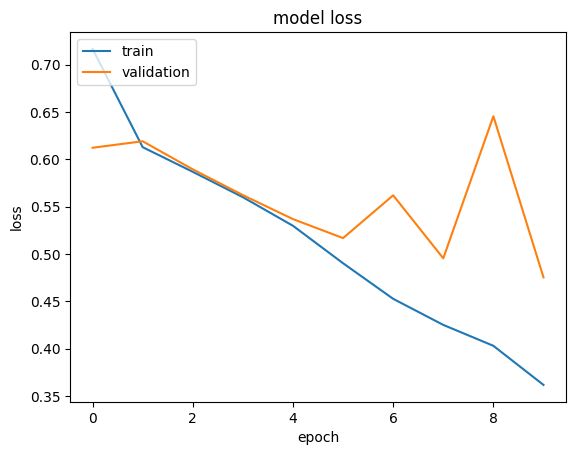

In [19]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

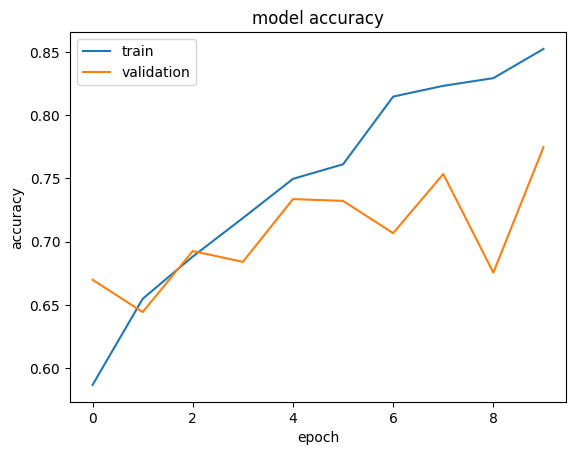

In [20]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Adding Maxpool layer to reduce parameters

In [21]:
# importing maxpool layer from keras
from keras.layers import MaxPool2D

In [22]:
# defining the model architecture with maxpool layer
model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
# adding maxpool layer after the convolutional layers
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))
model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [23]:
# summary of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 220, 220, 25)   │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 216, 216, 50)   │        31,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 145800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │    14,580,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,613,401 (55.75 MB)

 Trainable params: 14,613,401 (55.75 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 202ms/step - accuracy: 0.5896 - loss: 0.6894 - val_accuracy: 0.5779 - val_loss: 0.6594
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.6386 - loss: 0.6354 - val_accuracy: 0.6884 - val_loss: 0.6013
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.7018 - loss: 0.5951 - val_accuracy: 0.6955 - val_loss: 0.5753
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.7011 - loss: 0.5694 - val_accuracy: 0.6020 - val_loss: 0.6717
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.7296 - loss: 0.5530 - val_accuracy: 0.7252 - val_loss: 0.5398
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.7561 - loss: 0.5191 - val_accuracy: 0.6898 - val_loss: 0.5799
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.7482 - loss: 0.5128 - val_accuracy: 0.7351 - val_loss: 0.5220
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.7554 - loss: 0.5024 - val_accuracy: 

In [25]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
Accuracy on training set: 0.784325637910085


In [26]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Accuracy on validation set: 0.7549575070821529


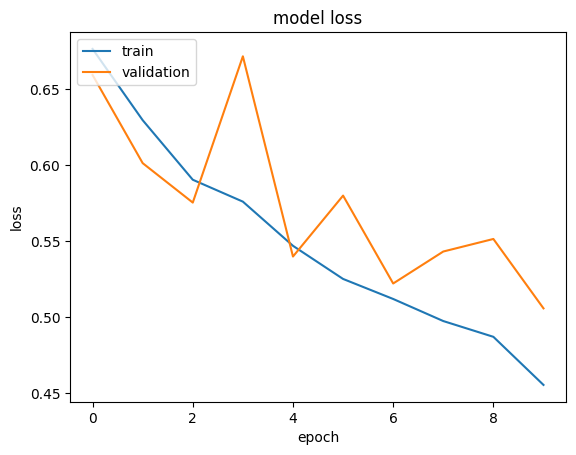

In [27]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

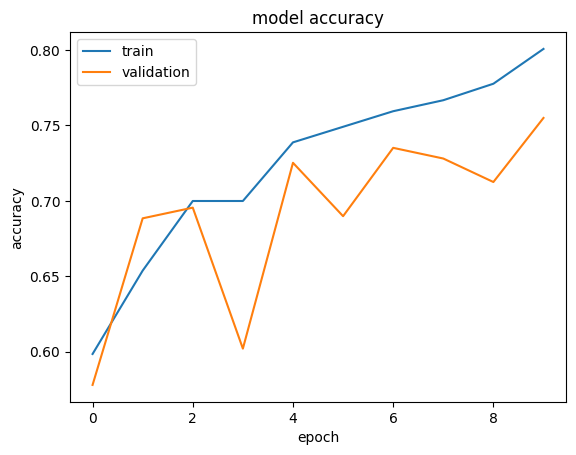

In [28]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Hyperparameter Tuning of Convolutional Neural Networks

1. increase number of convolutional layers
2. increase number of pooling layers
3. increase number of convolutional filters
4. change size of convolutional filters
5. change pooling type
6. change padding technique
7. change stride

#### Hyperparameters of fully connected layers

1. change activation function of hidden layer
2. increase hidden neurons
3. increase hidden layers
4. increase number of epochs
5. change optimizer
6. add batch normalization layer
7. add dropout layer

## 1. Increasing number of convolutional layers

In [29]:
# increase number of convolutional layers

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 25)   │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 216, 216, 50)   │        31,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 212, 212, 50)   │        62,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 140450)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    14,045,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,140,951 (53.94 MB)

 Trainable params: 14,140,951 (53.94 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 610ms/step - accuracy: 0.5521 - loss: 0.6862 - val_accuracy: 0.5609 - val_loss: 0.6874
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - accuracy: 0.6035 - loss: 0.6617 - val_accuracy: 0.6076 - val_loss: 0.6453
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.6448 - loss: 0.6431 - val_accuracy: 0.6771 - val_loss: 0.6051
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.6806 - loss: 0.5974 - val_accuracy: 0.6558 - val_loss: 0.6181
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.6915 - loss: 0.5996 - val_accuracy: 0.6856 - val_loss: 0.5842
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.7007 - loss: 0.5697 - val_accuracy: 0.6204 - val_loss: 0.7080
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.7344 - loss: 0.5583 - val_accuracy: 0.7238 - val_loss: 0.5390
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - accuracy: 0.7603 - loss: 0.5141 - val_accu

In [32]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step
Accuracy on training set: 0.7970838396111786


In [33]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
Accuracy on validation set: 0.7308781869688386


## 2. Increasing number of pooling layers

In [34]:
# increase number of pooling layers

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 220, 220, 25)   │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 55, 55, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 51, 51, 50)     │        31,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753,401 (2.87 MB)

 Trainable params: 753,401 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.5962 - loss: 0.6788 - val_accuracy: 0.5609 - val_loss: 0.6752
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5929 - loss: 0.6685 - val_accuracy: 0.5609 - val_loss: 0.6663
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5984 - loss: 0.6571 - val_accuracy: 0.6799 - val_loss: 0.6565
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6383 - loss: 0.6490 - val_accuracy: 0.6275 - val_loss: 0.6423
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6347 - loss: 0.6411 - val_accuracy: 0.6870 - val_loss: 0.6290
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6310 - loss: 0.6457 - val_accuracy: 0.7011 - val_loss: 0.6254
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6650 - loss: 0.6344 - val_accuracy: 0.6346 - val_loss: 0.6155
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6557 - loss: 0.6277 - val_accuracy: 0.7252 - 

In [37]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
Accuracy on training set: 0.7618469015795869


In [38]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Accuracy on validation set: 0.7478753541076487


## 3. Increasing number of convolutional filters

In [39]:
# increase number of convolutional filters

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(75, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [40]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 50)   │         3,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 216, 216, 75)   │        93,825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 218700)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │    21,870,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,967,826 (83.80 MB)

 Trainable params: 21,967,826 (83.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 57s 666ms/step - accuracy: 0.5569 - loss: 0.6997 - val_accuracy: 0.4504 - val_loss: 0.6968
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.6209 - loss: 0.6462 - val_accuracy: 0.6742 - val_loss: 0.6188
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.6829 - loss: 0.6096 - val_accuracy: 0.6870 - val_loss: 0.5782
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6891 - loss: 0.5925 - val_accuracy: 0.6374 - val_loss: 0.6313
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step - accuracy: 0.7125 - loss: 0.5628 - val_accuracy: 0.6218 - val_loss: 0.6612
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.7353 - loss: 0.5428 - val_accuracy: 0.7266 - val_loss: 0.5363
Epoch 7/10
 2/52 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.7031 - loss: 0.5608

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

## 4. Changing size of convolutional filters

In [ ]:
# change filter size for convolutional layer

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (3, 3), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(50, (3, 3), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

## 5. Changing pooling size

In [ ]:
# change pooling size

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(2, 2), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

## 6. Changing padding technique

In [ ]:
# change padding technique

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='same'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='same'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

## 7. Changing stride

In [ ]:
# changing stride

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(25, (5, 5), activation='relu', strides=(2, 2), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
# training the model
model_history = model.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_valid,y_valid))

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

## Combining Hyperparameter tuning

In [ ]:
# defining the model architecture with maxpool layer

model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))

model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(2, 2), padding='valid'))
model.add(Conv2D(50, (5, 5), activation='relu', strides=(1, 1), padding='valid'))
model.add(MaxPool2D(pool_size=(4, 4), padding='valid'))

model.add(Flatten())

model.add(Dense(units=100, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(rate=0.6))
model.add(Dense(units=100, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(rate=0.6))
model.add(Dense(units=1, activation='sigmoid'))

# compiling the model
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

In [ ]:
model.summary()

In [ ]:
# training the model for 100 epochs
model_history = model.fit(X_train, y_train, epochs=100, batch_size=32,validation_data=(X_valid,y_valid))

In [ ]:
# accuracy on training set
print('Accuracy on training set:', accuracy_score(y_train, np.where(model.predict(X_train)[:,0] < 0.5, 0,1)))

In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:,0] < 0.5, 0,1)))

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()